# Visualize TwinRNN Activity

This notebook loads the pretrained TwinRNN model, applies sparse perturbations during generated trials, and visualizes the resulting activity of the two recurrent populations. Run the cells from top to bottom.

## 1. Set Up Paths And Imports

Resolve the repository root, add `functions/` to Python's import path, and import the packages used by this demo.

In [1]:
# Configure repository-relative paths and import the analysis utilities used below.
from pathlib import Path
import sys
import random

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "RNN_models").exists() and (REPO_ROOT.parent / "RNN_models").exists():
    REPO_ROOT = REPO_ROOT.parent

FUNCTIONS_DIR = REPO_ROOT / "functions"
MODEL_DIR = REPO_ROOT / "RNN_models"
sys.path.insert(0, str(FUNCTIONS_DIR))

from decode_analyze import PerturbDecodeAnalyze
from get_folders import load_checkpoint_with_max_number
from parula_colormap import parula

## 2. Configure The Demo

Define the model dimensions, timing constants, noise settings, and analysis object used by the pretrained model. Durations are entered in milliseconds and then converted to simulation time steps.

In [2]:
# Fix the random seed and create the analysis helper with the demo parameters.
seed = 30
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

nUnit = 512
nInh = int(np.ceil(nUnit / 5))
nInput = 1
dt = 10
tau = 100 / dt

min_dur = int(6000 / dt)
max_dur = int(12000 / dt)
inputdur = int(30 / dt)

con_prob = 0
maxval = 0
ReLUalpha = 0.2

exp = 0.5
brown_scale = 3
nohigh = True

dim_method = "cca"
Dim = 100
lin_method = "act_stack"

analysis = PerturbDecodeAnalyze(
    min_dur, max_dur, dt, dim_method, Dim=Dim, lin_method=lin_method, nohigh=nohigh
)

## 3. Load The Pretrained Model

Load the saved noise weights and the latest TensorFlow checkpoint from `RNN_models/`, then build the model architecture used by the checkpoint.

In [3]:
# Build the RNN architecture, then load the latest saved checkpoint from RNN_models.
noise_weights = np.load(MODEL_DIR / "noise_weights.npy")
rank = np.shape(noise_weights)[0]

model = analysis.build_model_brown(
    nUnit=nUnit,
    nInh=nInh,
    nInput=nInput,
    con_prob=con_prob,
    maxval=maxval,
    ReLUalpha=ReLUalpha,
    seed1=seed,
    tau=tau,
    rank=rank,
    exp=exp,
    noise_weights=noise_weights,
)

checkpoint_path, checkpoint_epoch = load_checkpoint_with_max_number(MODEL_DIR)
model.load_weights(checkpoint_path)
print(f"Loaded checkpoint epoch {checkpoint_epoch}: {Path(checkpoint_path).name}")


Two checkpoint references resolved to different objects (<tensorflow.python.keras.layers.recurrent.RNN object at 0x0000020E9CE8A5C0> and <tensorflow.python.keras.layers.core.Dense object at 0x0000020E9CE8AD68>).

Two checkpoint references resolved to different objects (<tensorflow.python.keras.layers.core.Dense object at 0x0000020E9CE8AD68> and <tensorflow.python.keras.layers.merge.Concatenate object at 0x0000020EAF6BAC18>).
Loaded checkpoint epoch 9432: epoch_09432.ckpt


## 4. Generate Baseline Activity

Run unperturbed input trials through the model and compute mean activity profiles. These profiles are used to sort units by their peak response time in the final heatmaps.

In [4]:
# Generate baseline activity and sort units by the time of peak activity.
sample_size = 4
trial_num = 8
trial1 = 2
order = 1

activity_model = Model(inputs=model.input, outputs=[layer.output for layer in model.layers[1:]])
x, _, In_ons = analysis.makeInOut_sameint_brown(
    sample_size,
    trial_num,
    inputdur,
    nInput,
    order,
    brown_scale=brown_scale,
    rank=rank,
    exp=exp,
)

output_and_activities = activity_model.predict(x)
activities_A = output_and_activities[1]
activities_B = output_and_activities[2]

act_avg_A = analysis.avgAct2(activities_A, In_ons)
act_avg_B = analysis.avgAct2(activities_B, In_ons)

peak_times_A = np.argmax(act_avg_A[min_dur : min_dur + max_dur, :], axis=0)
peak_times_B = np.argmax(act_avg_B[min_dur : min_dur + max_dur, :], axis=0)
sort_id_A = np.argsort(peak_times_A)
sort_id_B = np.argsort(peak_times_B)

## 5. Apply Sparse Perturbations

Choose sparse perturbation times and apply noise perturbations to either RNN A or RNN B. The resulting activity is reshaped for plotting across consecutive trial segments.

In [5]:
# Apply sparse perturbations and reshape the resulting activity traces for plotting.
pert_noisesd = 0.8
pert_prob = 0.005
pert_A_prob = 0.5
stop = False

max_ind = int(np.floor((min_dur + max_dur) * (np.floor((trial_num - trial1) / 2) * 19 / 20)))
pert_number = int(np.floor(max_ind * pert_prob))
time_1 = []
for _ in range(sample_size):
    perturb_times = np.random.randint(0, max_ind, pert_number)
    perturb_times.sort()
    time_1.append(np.reshape(perturb_times, (1, -1)))
time_1 = np.concatenate(time_1, axis=0)
pert_which = np.random.uniform(size=time_1.shape) < pert_A_prob

actpart_A, actpart_B = analysis.perturb_and_decode_noise_prob2_brown(
    trial1,
    time_1,
    pert_which,
    order,
    pert_noisesd,
    stop,
    sample_size,
    trial_num,
    inputdur,
    nInput,
    nUnit,
    nInh,
    con_prob,
    maxval,
    ReLUalpha,
    seed,
    tau,
    model,
    brown_scale,
    rank,
    exp=exp,
    noise_weights=noise_weights,
)

pert_ind = np.zeros((analysis.x.shape[0], analysis.x.shape[1], 2))
for i in range(pert_which.shape[0]):
    for k in range(pert_which.shape[1]):
        target = 0 if pert_which[i, k] else 1
        pert_ind[i, analysis.pert_ind[i, k], target] = 1

pert_ind_stack = analysis.concatAct_sliced(pert_ind, analysis.In_ons)

act_A = np.transpose(actpart_A, axes=(0, 2, 1))
act_B = np.transpose(actpart_B, axes=(0, 2, 1))
act_x = np.transpose(analysis.x_part, axes=(0, 2, 1))

act_A_2 = np.concatenate([act_A[:, i, :] for i in range(act_A.shape[1])], axis=0)
act_B_2 = np.concatenate([act_B[:, i, :] for i in range(act_B.shape[1])], axis=0)
act_x_2 = np.concatenate([act_x[i, :, :] for i in range(act_x.shape[0])], axis=1)
x_2 = np.concatenate(pert_ind_stack, axis=0)

## 6. Plot The Activity Visualization

Plot the input and perturbation events above sorted activity heatmaps for RNN A and RNN B.

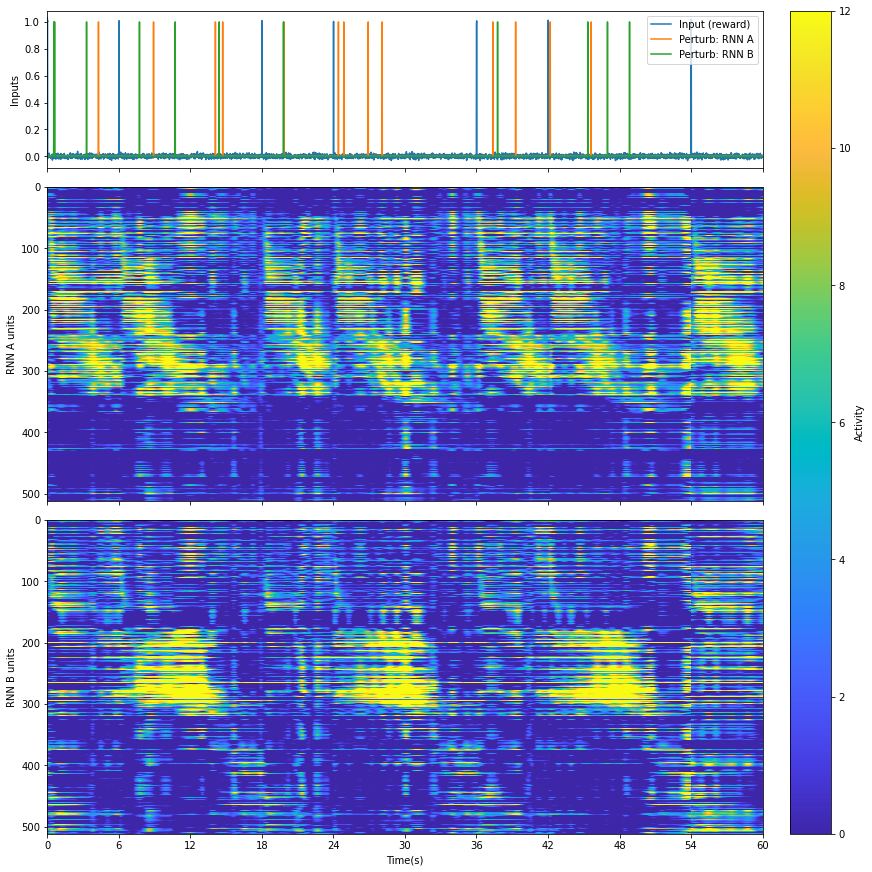

In [6]:
# Plot the input, perturbation timing, and sorted activity from both RNN populations.
vmax = 12
start = 0
end = 6000
window_length = end - start
tick_step = 600
tick_positions = np.arange(0, window_length + 1, tick_step)
tick_labels = [f"{tick / 100:g}" for tick in tick_positions]

fig, axs = plt.subplots(
    3,
    1,
    figsize=(12, 12),
    constrained_layout=True,
    sharex=True,
    gridspec_kw={"height_ratios": [1, 2, 2]},
)

axs[0].plot(act_x_2[0, start:end], label="Input (reward)")
axs[0].plot(x_2[start:end, 0], label="Perturb: RNN A")
axs[0].plot(x_2[start:end, 1], label="Perturb: RNN B")
axs[0].set_ylabel("Inputs")
axs[0].legend(loc="upper right")
axs[0].grid(False)

axs[1].imshow(
    act_A_2[start:end, sort_id_A].T,
    aspect="auto",
    origin="upper",
    cmap=parula,
    interpolation="nearest",
    vmin=0,
    vmax=vmax,
)
axs[1].set_ylabel("RNN A units")

im_b = axs[2].imshow(
    act_B_2[start:end, sort_id_B].T,
    aspect="auto",
    origin="upper",
    cmap=parula,
    interpolation="nearest",
    vmin=0,
    vmax=vmax,
)
axs[2].set_ylabel("RNN B units")
axs[2].set_xlim(0, window_length)
axs[2].set_xticks(tick_positions)
axs[2].set_xticklabels(tick_labels)
axs[2].set_xlabel("Time(s)")

cbar = fig.colorbar(im_b, ax=axs.tolist(), fraction=0.025, pad=0.02)
cbar.set_label("Activity")

plt.show()